# Deep Q-Network Agent for CartPole-v1

**Author:** Prateek Shukla  
**Framework:** PyTorch + Gymnasium  

This project implements a Deep Q-Network (DQN) agent from scratch to solve the CartPole-v1 environment using reinforcement learning.

The goal is to train an agent that learns to balance a pole on a moving cart by maximizing cumulative reward.


## Problem Statement

The CartPole-v1 environment consists of:

- **State Space:** 4 continuous values  
  (cart position, cart velocity, pole angle, pole angular velocity)

- **Action Space:** 2 discrete actions  
  (move left or move right)

The objective is to train an agent that keeps the pole balanced for as long as possible.

The environment is considered solved when the average reward over 100 consecutive episodes reaches 475+.


## DQN Implementation Details

The following core components were implemented from scratch:

1. Experience Replay Buffer  
2. Target Network for stable Q-learning  
3. Epsilon-Greedy exploration strategy  
4. Step-based target network updates  
5. Gradient clipping for stability  
6. Huber Loss instead of MSE  
7. Multi-seed training for robustness

The implementation avoids over-engineering and follows the original DQN structure.


## Final Hyperparameters Used

- Learning Rate: 5e-4  
- Replay Buffer Size: 10000  
- Batch Size: 64  
- Discount Factor (γ): 0.99  
- Epsilon Decay: 0.995 (episode-level)  
- Target Update Steps: 200  
- Training Episodes: 1000  
- Gradient Clipping: 1.0  
- Loss Function: Huber Loss  

Multiple random seeds were used to ensure performance was not dependent on lucky initialization.


# Load Reward Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rewards_42 = np.load("rewards_seeds_42.npy")
rewards_7 = np.load("rewards_seeds_7.npy")
rewards_123 = np.load("rewards_seeds_123.npy")


# Raw Reward Plot

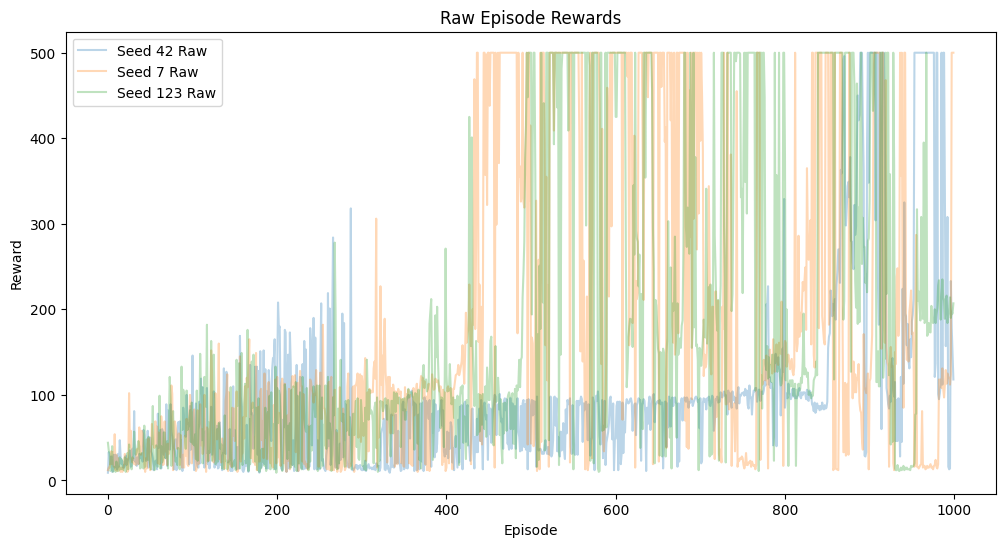

In [2]:
plt.figure(figsize=(12,6))

plt.plot(rewards_42, alpha=0.3, label="Seed 42 Raw")
plt.plot(rewards_7, alpha=0.3, label="Seed 7 Raw")
plt.plot(rewards_123, alpha=0.3, label="Seed 123 Raw")

plt.title("Raw Episode Rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.show()


# Rolling Average Function

In [3]:
def moving_average(data, window=100):
    return np.convolve(data, np.ones(window)/window, mode='valid')


# Smoothed Performance Plot

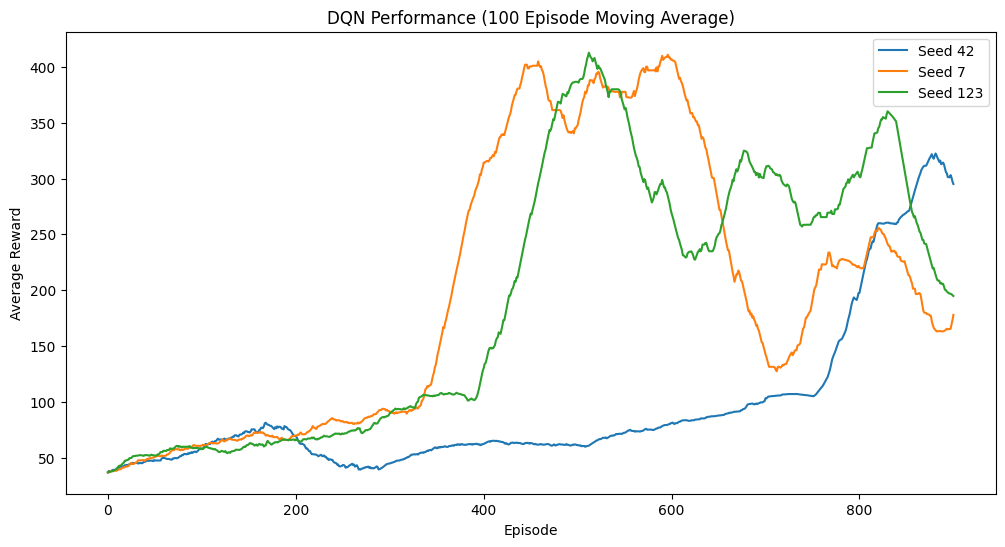

In [4]:
plt.figure(figsize=(12,6))

plt.plot(moving_average(rewards_42), label="Seed 42")
plt.plot(moving_average(rewards_7), label="Seed 7")
plt.plot(moving_average(rewards_123), label="Seed 123")

plt.title("DQN Performance (100 Episode Moving Average)")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.legend()
plt.show()


# Final Performance Comparison

In [5]:
print("Final 100 Episode Average:")

print("Seed 42:", np.mean(rewards_42[-100:]))
print("Seed 7 :", np.mean(rewards_7[-100:]))
print("Seed 123:", np.mean(rewards_123[-100:]))

print("\nMaximum Reward Achieved:")

print("Seed 42:", np.max(rewards_42))
print("Seed 7 :", np.max(rewards_7))
print("Seed 123:", np.max(rewards_123))


Final 100 Episode Average:
Seed 42: 295.09
Seed 7 : 177.91
Seed 123: 194.79

Maximum Reward Achieved:
Seed 42: 500.0
Seed 7 : 500.0
Seed 123: 500.0


## Development Improvements

During experimentation, the following refinements were implemented:

- Changed epsilon decay from step-level to episode-level  
- Replaced MSE Loss with Huber Loss for stability  
- Added gradient clipping to prevent exploding gradients  
- Reduced target update interval from 500 to 200 steps  
- Trained across multiple random seeds  
- Tracked and saved the best performing model  

These changes improved stability and reduced late-training collapse.


## Training Observations

- Early episodes show high variance due to exploration.
- Performance improves steadily as epsilon decays.
- Different seeds show different convergence speeds.
- Seed 7 converged slower compared to others.
- Some instability observed in late training phases.
- Reinforcement learning performance is highly sensitive to initialization and randomness.

This highlights the importance of multi-seed evaluation.


## Conclusion

The DQN agent successfully learned to balance the pole and achieved near-optimal performance during evaluation.

Key takeaways:

- Proper target updates significantly impact stability.
- Huber loss improves robustness over MSE.
- Gradient clipping prevents unstable value explosions.
- Multi-seed training is essential for fair evaluation.
- Reinforcement learning is inherently stochastic.

The final implementation remains clean, modular, and faithful to the core DQN algorithm.
